PyTorch implementation of the **VGGNet** discussed in _'Very Deep Convolutional Nets for Large-Scale Image Recognition'_ (Simonyan and Zisserman, 2014)

In [1]:
import os
import time     # for recording training duration
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# FOR REPRODUCIBILITY
seed = 26

os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # forces cuDNN to use deterministic algorithms only
    torch.backends.cudnn.deterministic = True
    # disables cuDNN autotuner that selects optimal algorithm based on hardware
    torch.backends.cudnn.benchmark = False

# force shuffling of samples in dataloader to be deterministic
generator = torch.Generator().manual_seed(seed)

In [5]:
# hyperparameters
learningrate = 0.01
batchsize = 128
epochs = 75

momentum = 0.9
weightdecay = 5e-4

We'll be using the Imagenette dataset, a subset of ImageNet consisting of 10 distinct classes of 224x224 images.

In [6]:
datapath = "../data"

# loading Imagenette
train_imagenette = datasets.Imagenette(
    root=datapath,
    split="train",
    download=True,
    transform=transforms.Compose([
        transforms.Resize(256),
        # trying random crop here to test if it helps
        transforms.RandomCrop(224),
        transforms.ToTensor()
    ])
)
test_imagenette = datasets.Imagenette(
    root=datapath,
    split="val",
    download=True,
    transform=transforms.Compose([
        transforms.Resize(256),
        # cropping to centre for deterministic evaluation
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])
)

trainloader_imagenette = DataLoader(
    train_imagenette,
    batch_size=batchsize,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    generator=generator
)
testloader_imagenette = DataLoader(
    test_imagenette,
    batch_size=batchsize,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

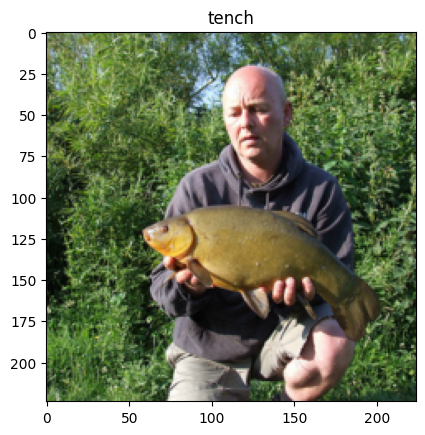

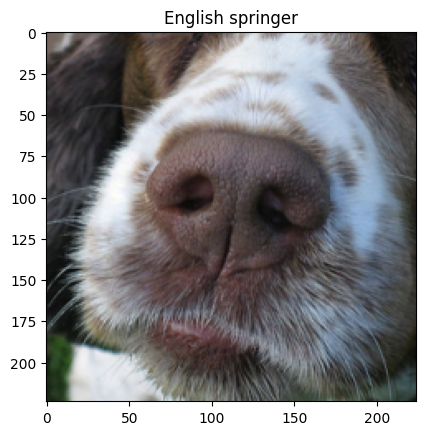

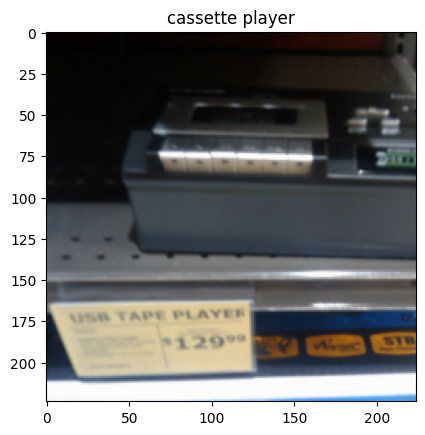

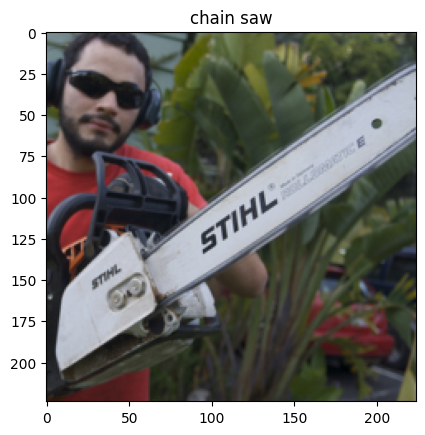

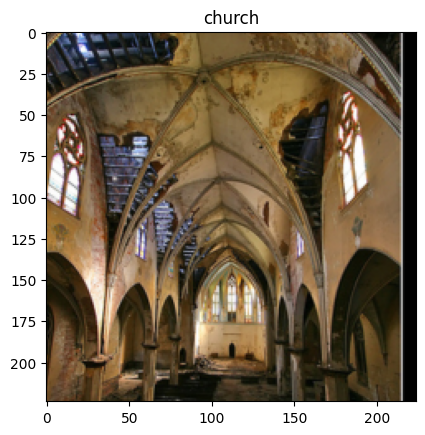

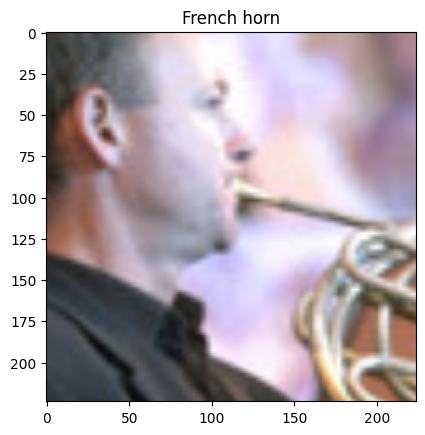

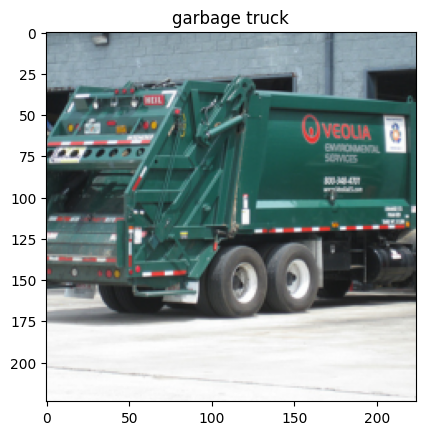

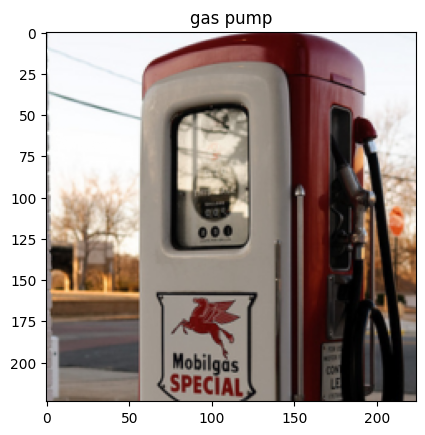

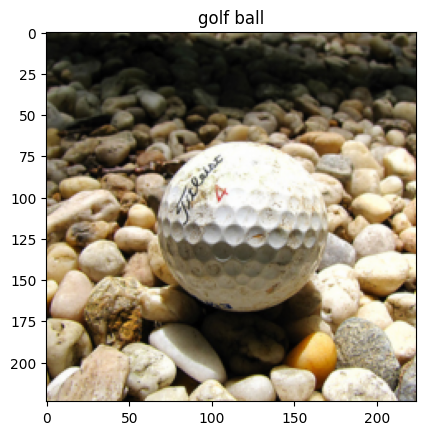

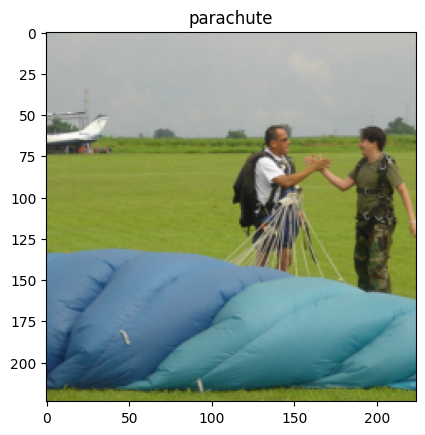

In [7]:
classes = train_imagenette.classes

images, labels = next(iter(trainloader_imagenette))
for i in range(10):
    index = np.argmax(labels.numpy() == i)
    plt.imshow(images[index].permute(1, 2, 0))
    plt.title(classes[i][0])
    plt.show()

The paper recommends preprocessing the image inputs by subtracting the mean RGB value computed on the training set from each pixel. To do this, we'll calculate the mean and standard deviation over our train dataset to normalise image inputs to the network.

In [8]:
# function to return normalisation transform, applied during training loop
def normalise_inputs(dataloader):
    channelwise_sums = torch.zeros(3)
    channelwise_squared_sums = torch.zeros(3)
    totalpixels = 0

    for images, _ in dataloader:
        batchpixels = images.shape[0] * images.shape[2] * images.shape[3]
        totalpixels += batchpixels

        # dimensions are [batchsize, channels, height, width]
        channelwise_sums += torch.sum(images, dim=[0, 2, 3])
        channelwise_squared_sums += torch.sum(images**2, dim=[0, 2, 3])

    mean = channelwise_sums / totalpixels
    # using variance = E[X^2] - (E[X])^2
    variance = (channelwise_squared_sums / totalpixels) - mean**2
    stddev = torch.sqrt(variance)

    normaliser = transforms.Normalize(mean=mean, std=stddev)
    return normaliser

In [9]:
inputnormaliser = normalise_inputs(trainloader_imagenette)

In [10]:
class VGGNet(nn.Module):
    def __init__(self, inputsize:int, classcount:int, arch:int=16, flag_batchnorm:bool=True, flag_GAP:bool=False):
        super().__init__()

        if arch not in (16, 19):
            print("Invalid architecture specified. VGG16 selected as default.")
        else:
            print(f"VGG{arch} architecture selected.")
        self.arch = arch

        # flags to toggle batchnorm and using a convolutional GAP layer instead of FC layer
        self.batchnorm = flag_batchnorm
        self.GAP = flag_GAP

        # conv layers before 1st pool
        self.conv1 = nn.Conv2d(in_channels=inputsize, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=64) if self.batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_features=64) if self.batchnorm else nn.Identity()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # conv layers before 2nd pool
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=128) if self.batchnorm else nn.Identity()
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(num_features=128) if self.batchnorm else nn.Identity()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # conv layers before 3rd pool
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(num_features=256) if self.batchnorm else nn.Identity()
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(num_features=256) if self.batchnorm else nn.Identity()
        self.conv7 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(num_features=256) if self.batchnorm else nn.Identity()
        # optional 4th conv here for VGG19
        self.convplus1 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1) if self.arch == 19 else nn.Identity()
        self.bnplus1 = nn.BatchNorm2d(num_features=256) if self.batchnorm and self.arch == 19 else nn.Identity()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # conv layers before 4th pool
        self.conv8 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(num_features=512) if self.batchnorm else nn.Identity()
        self.conv9 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn9 = nn.BatchNorm2d(num_features=512) if self.batchnorm else nn.Identity()
        self.conv10 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn10 = nn.BatchNorm2d(num_features=512) if self.batchnorm else nn.Identity()
        # optional 4th conv here for VGG19
        self.convplus2 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1) if self.arch == 19 else nn.Identity()
        self.bnplus2 = nn.BatchNorm2d(num_features=512) if self.batchnorm and self.arch == 19 else nn.Identity()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # conv layers before 5th pool
        self.conv11 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn11 = nn.BatchNorm2d(num_features=512) if self.batchnorm else nn.Identity()
        self.conv12 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn12 = nn.BatchNorm2d(num_features=512) if self.batchnorm else nn.Identity()
        self.conv13 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.bn13 = nn.BatchNorm2d(num_features=512) if self.batchnorm else nn.Identity()
        # optional 4th conv here for VGG19
        self.convplus3 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1) if self.arch == 19 else nn.Identity()
        self.bnplus3 = nn.BatchNorm2d(num_features=512) if self.batchnorm and self.arch == 19 else nn.Identity()
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layers
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=512*7*7, out_features=4096),
            nn.ReLU(),
            nn.Dropout(p=0.5)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Dropout(p=0.5)
        )
        self.fc3 = nn.Linear(in_features=4096, out_features=classcount)

        # conv layer to replace FC layers optionally using GAP
        self.fullconv = nn.Conv2d(in_channels=512, out_channels=classcount, kernel_size=1)

    def forward(self, o):
        o = F.relu(self.bn1(self.conv1(o)))
        o = F.relu(self.bn2(self.conv2(o)))
        o = self.pool1(o)

        o = F.relu(self.bn3(self.conv3(o)))
        o = F.relu(self.bn4(self.conv4(o)))
        o = self.pool2(o)

        o = F.relu(self.bn5(self.conv5(o)))
        o = F.relu(self.bn6(self.conv6(o)))
        o = F.relu(self.bn7(self.conv7(o)))
        o = F.relu(self.bnplus1(self.convplus1(o)))
        o = self.pool3(o)

        o = F.relu(self.bn8(self.conv8(o)))
        o = F.relu(self.bn9(self.conv9(o)))
        o = F.relu(self.bn10(self.conv10(o)))
        o = F.relu(self.bnplus2(self.convplus2(o)))
        o = self.pool4(o)

        o = F.relu(self.bn11(self.conv11(o)))
        o = F.relu(self.bn12(self.conv12(o)))
        o = F.relu(self.bn13(self.conv13(o)))
        o = F.relu(self.bnplus3(self.convplus3(o)))
        o = self.pool5(o)

        if self.GAP:
            o = self.fullconv(o)
            logits = F.adaptive_avg_pool2d(o, 1)
            logits = torch.flatten(logits, 1)
        else:
            # here, unless we use adaptive pooling to restrict input to FC layers to be 512*7*7, it would crash for image sizes other than 224x224
            o = torch.flatten(o, 1)
            o = self.fc1(o)
            o = self.fc2(o)
            logits = self.fc3(o)

        return logits

In [11]:
def train(model, trainloader, testloader, inputnormaliser, epochs, learningrate, weightdecay, momentum):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if torch.cuda.device_count() > 1:
        print(f"[Using {torch.cuda.device_count()} GPUs]")
        model = nn.DataParallel(model)

    model.to(device)
    # loss function
    criterion = nn.CrossEntropyLoss()
    # the paper uses SGD with momentum and weight decay
    optimiser = torch.optim.SGD(model.parameters(), lr=learningrate, momentum=momentum, weight_decay=weightdecay)
    # scheduler that reduces learning rate when validation accuracy plateaus
    # here, patience denotes number of epochs to wait before reducing learning rate on plateau
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='max', factor=0.1, patience=5)

    start = time.time()
    for epoch in range(epochs):
        model.train()
        runningloss = 0.0
        correct_train_samples = 0
        total_train_samples = 0

        for images, labels in trainloader:
            # move data to gpu
            images = images.to(device)
            labels = labels.to(device)

            # apply input normalisation as described in the paper
            images = inputnormaliser(images)

            # clear gradients
            optimiser.zero_grad()
            # forward pass
            logits = model(images)
            # loss calc
            loss = criterion(logits, labels)
            # backward pass
            loss.backward()
            # weight update
            optimiser.step()

            # loss returned is a tensor, so .item() returns float value
            # multiply by batch size to get net loss for batch
            runningloss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, axis=1)
            total_train_samples += labels.size(0)
            correct_train_samples += (predicted == labels).sum().item()

        trainloss = runningloss / total_train_samples
        trainacc = 100 * (correct_train_samples / total_train_samples)

        # we will also evaluate on test set after each epoch for ease of adjusting hyperparameters
        model.eval()
        correct_test_samples = 0
        total_test_samples = 0

        # freezes weights so model doesn't learn from test set
        with torch.no_grad():
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)

                # we'll apply the normaliser here asw
                images = inputnormaliser(images)

                logits = model(images)
                _, predicted = torch.max(logits, axis=1)
                total_test_samples += labels.size(0)
                correct_test_samples += (predicted == labels).sum().item()

        testacc = 100 * (correct_test_samples / total_test_samples)

        # lr update
        scheduler.step(testacc)

        # retrieve current learning rate
        curr_lr = optimiser.param_groups[0]['lr']

        print(f"epoch: {epoch+1}/{epochs}\tcurrent LR: {curr_lr:.6f}\ttrain loss: {trainloss:.4f}\ttrain acc: {trainacc:.2f}%\ttest acc: {testacc:.2f}%")
    
    print("Finished training. Time elapsed: {:.2f} minutes".format((time.time() - start)/60))
    return model

We'll evaluate performance of the VGG16 and VGG19 architectures on the Imagenette dataset, first using the architecture as described in the paper with FC layers for classification. Then, we'll test a version that replaces the FC layers with global average pooling to see if it impacts training time or accuracy.

In [12]:
# vgg16_fc = VGGNet(inputsize=3, classcount=10, arch=16, flag_batchnorm=True, flag_GAP=False)
# trained_vgg16_fc = train(vgg16_fc, trainloader_imagenette, testloader_imagenette, inputnormaliser, epochs, learningrate, weightdecay, momentum)

In [13]:
# vgg19_fc = VGGNet(inputsize=3, classcount=10, arch=19, flag_batchnorm=True, flag_GAP=False)
# trained_vgg19_fc = train(vgg19_fc, trainloader_imagenette, testloader_imagenette, inputnormaliser, epochs, learningrate, weightdecay, momentum)

In [14]:
vgg16_gap = VGGNet(inputsize=3, classcount=10, arch=16, flag_batchnorm=True, flag_GAP=True)
trained_vgg16_gap = train(vgg16_gap, trainloader_imagenette, testloader_imagenette, inputnormaliser, epochs, learningrate, weightdecay, momentum)

VGG16 architecture selected.
Using device: cuda
[Using 4 GPUs]
epoch: 1/75	current LR: 0.010000	train loss: 1.5499	train acc: 48.10%	test acc: 42.19%
epoch: 2/75	current LR: 0.010000	train loss: 1.1714	train acc: 61.99%	test acc: 56.46%
epoch: 3/75	current LR: 0.010000	train loss: 0.9827	train acc: 68.11%	test acc: 48.25%
epoch: 4/75	current LR: 0.010000	train loss: 0.8630	train acc: 72.50%	test acc: 67.11%
epoch: 5/75	current LR: 0.010000	train loss: 0.7892	train acc: 74.54%	test acc: 75.44%
epoch: 6/75	current LR: 0.010000	train loss: 0.7152	train acc: 76.95%	test acc: 71.26%
epoch: 7/75	current LR: 0.010000	train loss: 0.6662	train acc: 78.52%	test acc: 73.86%
epoch: 8/75	current LR: 0.010000	train loss: 0.6189	train acc: 80.09%	test acc: 72.20%
epoch: 9/75	current LR: 0.010000	train loss: 0.5795	train acc: 81.25%	test acc: 66.78%
epoch: 10/75	current LR: 0.010000	train loss: 0.5395	train acc: 82.64%	test acc: 75.95%
epoch: 11/75	current LR: 0.010000	train loss: 0.4942	train acc: 84

The VGG16 network with global average pooling delivers a maximum test accuracy of 91.69% at epoch 68/75.

We see that the training loss doesn't constantly decrease over time, possibly because we have used ReduceLROnPLateau, which modifies the learning rate based on the test accuracy. This likely leads to some "overshooting", as the learning rate remains at its value unless test accuracy hasn't improved for 5 epochs. This is unlike the CosineAnnealing scheduler we used earlier, which gradually brings down the learning rate to zero in a smooth curve, which depends only on the total number of epochs.

In [15]:
vgg19_gap = VGGNet(inputsize=3, classcount=10, arch=19, flag_batchnorm=True, flag_GAP=True)
trained_vgg19_gap = train(vgg19_gap, trainloader_imagenette, testloader_imagenette, inputnormaliser, epochs, learningrate, weightdecay, momentum)

VGG19 architecture selected.
Using device: cuda
[Using 4 GPUs]
epoch: 1/75	current LR: 0.010000	train loss: 1.6381	train acc: 43.75%	test acc: 22.98%
epoch: 2/75	current LR: 0.010000	train loss: 1.2007	train acc: 60.65%	test acc: 51.54%
epoch: 3/75	current LR: 0.010000	train loss: 1.0366	train acc: 66.17%	test acc: 58.73%
epoch: 4/75	current LR: 0.010000	train loss: 0.9434	train acc: 70.04%	test acc: 66.50%
epoch: 5/75	current LR: 0.010000	train loss: 0.8375	train acc: 72.43%	test acc: 68.03%
epoch: 6/75	current LR: 0.010000	train loss: 0.7599	train acc: 75.71%	test acc: 58.70%
epoch: 7/75	current LR: 0.010000	train loss: 0.7391	train acc: 76.32%	test acc: 72.87%
epoch: 8/75	current LR: 0.010000	train loss: 0.6396	train acc: 79.56%	test acc: 63.77%
epoch: 9/75	current LR: 0.010000	train loss: 0.6201	train acc: 79.88%	test acc: 53.07%
epoch: 10/75	current LR: 0.010000	train loss: 0.5813	train acc: 81.27%	test acc: 74.47%
epoch: 11/75	current LR: 0.010000	train loss: 0.5444	train acc: 82

The VGG19 network with global average pooling reaches a maximum test accuracy of 90.68% at epoch 59/75.

According to the paper, VGG19 is supposed to achieve greater accuracy than VGG16 due to the deeper network (deeper architecture was achievable due to the use of 3x3 convolutions). The difference in experimental results may be due to different hyperparameters used or the use of Imagenette dataset (with 10 classes) instead of standard ImageNet.